In [62]:
import pandas as pd
from github_helper import from_github
all_politician_edges = pd.read_csv(from_github('/edges/politician/Period/politician_edges_general_by_Period.csv'))

Centrality:
* Degree
* Closeness
* Betweness
* Eigenvector

Cliques - Set of nodes all internally connected

In [55]:
import json
party_colors = json.loads(from_github('/party_colors.json').read())

politician_colors = {party: color for party, color in party_colors.items()}

In [63]:
all_politician_edges

,source,target,source_party,target_party,Period,total_votes_shared,total_votes_agreed,weight,topic
0,Anders Fogh Rasmussen,Anders Møller,Venstre,Uden for Folketingsgrupperne,65,2,2.0,1.000000,general
1,Anders Fogh Rasmussen,Anita Knakkergaard,Venstre,Dansk Folkeparti,65,3,3.0,1.000000,general
2,Anders Fogh Rasmussen,Anne Baastrup,Venstre,Socialistisk Folkeparti,65,1,1.0,1.000000,general
3,Anders Fogh Rasmussen,Anne Grete Holmsgaard (udpeget af SF),Venstre,Socialistisk Folkeparti,65,3,1.0,0.333333,general
4,Anders Fogh Rasmussen,Anne-Marie Meldgaard,Venstre,Socialdemokratiet,65,3,0.0,0.000000,general
...,...,...,...,...,...,...,...,...,...
102070,Tina Cartey Hansen,Yildiz Akdogan,Det Konservative Folkeparti,Socialdemokratiet,71,2,2.0,1.000000,general
102071,Tobias Grotkjær Elmstrøm,Trine Pertou Mach,Moderaterne,Enhedslisten,71,110,36.0,0.327273,general
102072,Tobias Grotkjær Elmstrøm,Victoria Velasquez,Moderaterne,Enhedslisten,71,1,1.0,1.000000,general
102073,Trine Pertou Mach,Victoria Velasquez,Enhedslisten,Enhedslisten,71,5,5.0,1.000000,general


In [60]:
all_politician_edges['Period'].unique()

array([65, 66, 67, 68, 69, 70, 71])

Edges before filter: 102075, after filter: 56147


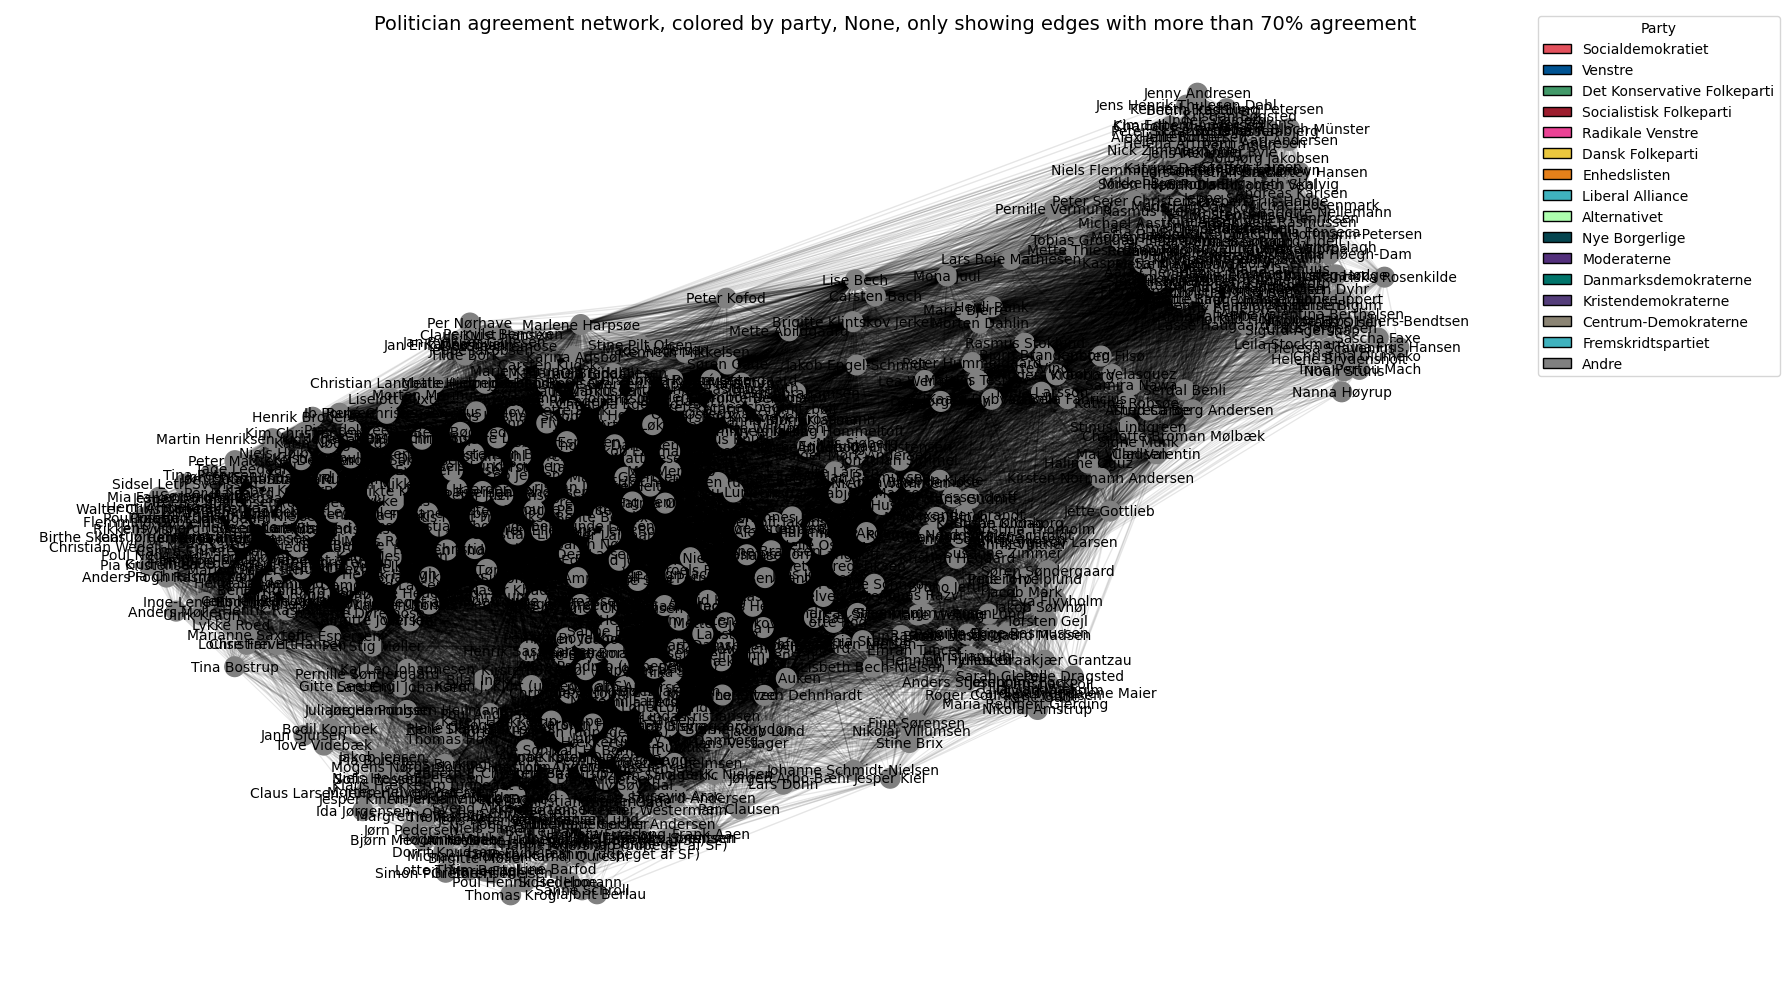

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch


def edgelist_and_graph_to_visualization(edgelist, agreement_threshold=0.7, stats=True, period_title=None, topic=None):
    

    len_before = len(edgelist)
    edgelist = edgelist[edgelist['weight'] > agreement_threshold]
    G = nx.from_pandas_edgelist(edgelist, 'source', 'target', edge_attr='weight')

    figure, axs = plt.subplots(1,1,figsize = (18,10)) #Width, Height


    #topic = edgelist['topics_simple'].unique()



    #NETWULF FOR DRAWING GRAPHS could be interesting. Danny has worked with it before
    pos = nx.forceatlas2_layout(G
                                            , seed = 42
                                            , weight = "weight"
                                            , max_iter = 5000
                                            )

    # nodes
    df_draw = edgelist[edgelist['weight'] > agreement_threshold]
    if stats:
        print(f"Edges before filter: {len_before}, after filter: {len(df_draw)}")

    #Get the edges and widths to draw
    edges = list(zip(df_draw['source'], df_draw['target']))
    edge_widths = df_draw['weight'].tolist()


    nx.draw_networkx_nodes(G, pos, node_size=200, ax=axs, node_color=[politician_colors.get(node, '#808080') for node in G.nodes()])

    # edges
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=[w * 1 for w in edge_widths], alpha = 0.1, ax = axs)


    # node labels
    nx.draw_networkx_labels(G, pos, font_size=10, ax = axs)

    # Build legend: only parties that appear in politician_colors
    used_colors = set(politician_colors.values())

    legend_handles = []
    for party, color in party_colors.items():
        if color in used_colors:
            legend_handles.append(Patch(facecolor=color, edgecolor='black', label=party))

    axs.legend(handles=legend_handles, title="Party", loc="upper left", bbox_to_anchor=(1, 1))



    # ax.margins(0.08)
    plt.axis("off")
    plt.tight_layout()
    plt.suptitle(f"Politician agreement network, colored by party, {period_title}, only showing edges with more than {agreement_threshold*100:.0f}% agreement", fontsize = 14)
    # plt.title(f"Topic is {topic[0]}")

    plt.show()
    
# all_politician_edges = all_politician_edges[all_politician_edges['source'] != all_politician_edges['target']]
# all_politician_edges = all_politician_edges[~all_politician_edges['source'].isin(['Folkaflokkurin', 'Sambandsflokkurin', 'Javnaðarflokkurin', 'Tjóðveldisflokkurin', 'Nunatta Qitornai', 'Inuit Ataqatigiit', 'Naleraq', 'Tjóðveldi', 'Siumut'])]
# all_politician_edges = all_politician_edges[~all_politician_edges['target'].isin(['Folkaflokkurin', 'Sambandsflokkurin', 'Javnaðarflokkurin', 'Tjóðveldisflokkurin', 'Nunatta Qitornai', 'Inuit Ataqatigiit', 'Naleraq', 'Tjóðveldi', 'Siumut'])]

# edgelist_and_graph_to_visualization(all_politician_edges,0.7)

In [41]:
all_politician_edges

,source,target,Period,total_votes_shared,total_votes_agreed,weight,topic
0,Danmarksdemokraterne,Danmarksdemokraterne,65,524,512.0,0.977099,General
1,Danmarksdemokraterne,Dansk Folkeparti,65,8606,8507.0,0.988496,General
2,Danmarksdemokraterne,Det Konservative Folkeparti,65,5331,5230.0,0.981054,General
3,Danmarksdemokraterne,Enhedslisten,65,315,110.0,0.349206,General
4,Danmarksdemokraterne,Inuit Ataqatigiit,65,39,3.0,0.076923,General
...,...,...,...,...,...,...,...
1043,Socialistisk Folkeparti,Uden for folketingsgrupperne,71,30387,20806.0,0.684701,General
1044,Socialistisk Folkeparti,Venstre,71,178905,130250.0,0.728040,General
1045,Uden for folketingsgrupperne,Uden for folketingsgrupperne,71,3016,2068.0,0.685676,General
1046,Uden for folketingsgrupperne,Venstre,71,51308,41721.0,0.813148,General


KeyError: 'Period'

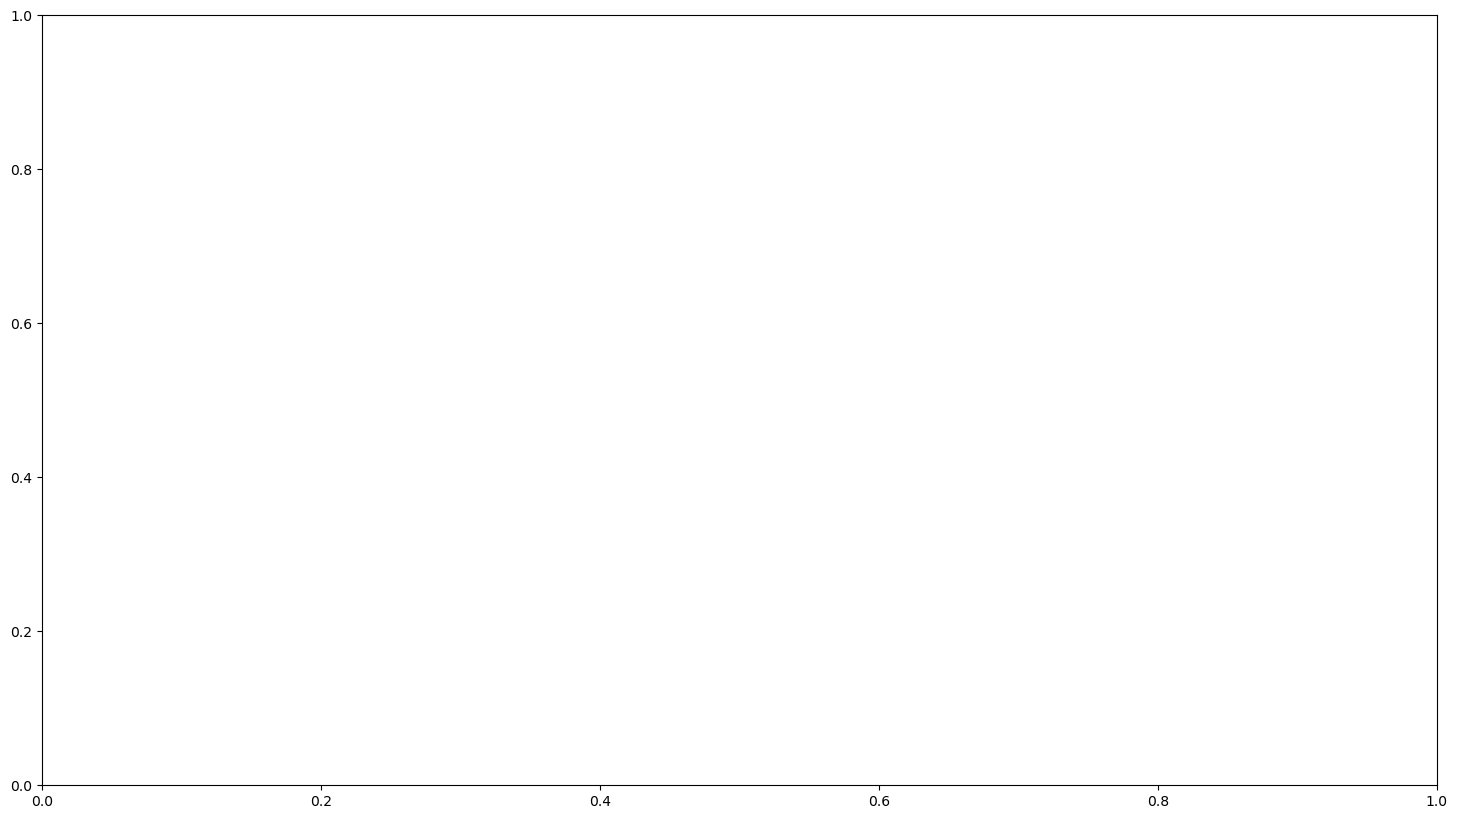

In [71]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import defaultdict
import sys


def filter_and_aggregate(df, periods=None):
    """
    Filter political voting data by period and aggregate across periods.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with columns: source, target, source_party, target_party, 
        Period, total_votes_shared, total_votes_agreed, weight, topic
    periods : list of int, or None
        List of period numbers to include (e.g., [65, 66, 67]). 
        If None, includes all periods.
    
    Returns:
    --------
    pandas.DataFrame
        Aggregated DataFrame with one row per politician pair, with columns:
        source, target, source_party, target_party, total_votes_shared, 
        total_votes_agreed, weight
    """
    df = df.copy()
    
    # Filter by periods if specified
    if periods is not None:
        df = df[df['Period'].isin(periods)]
    
    # Group by politician pairs and aggregate
    # Keep party info (should be constant for each politician)
    agg_df = df.groupby(['source', 'target']).agg({
        'source_party': 'first',  # Party should be constant per politician
        'target_party': 'first',
        'total_votes_shared': 'sum',
        'total_votes_agreed': 'sum'
    }).reset_index()
    
    # Recalculate weight as agreed/shared
    agg_df['weight'] = agg_df['total_votes_agreed'] / agg_df['total_votes_shared']
    
    return agg_df


def high_salience_skeleton(table, undirected=False, return_self_loops=False):
    """
    Calculate high salience skeleton backbone (from course materials).
    
    This function identifies statistically significant edges based on shortest path
    calculations through the network.
    """
    sys.stderr.write("Calculating HSS score...\n")
    table = table.copy()
    table['distance'] = 1.0 / table['nij']
    nodes = set(table['src']) | set(table['trg'])
    G = nx.from_pandas_edgelist(table, source='src', target='trg', 
                                 edge_attr='distance', create_using=nx.DiGraph())
    cs = defaultdict(float)
    
    for s in nodes:
        pred = defaultdict(list)
        dist = {t: float('inf') for t in nodes}
        dist[s] = 0.0
        Q = defaultdict(list)
        for w in dist:
            Q[dist[w]].append(w)
        S = []
        
        while len(Q) > 0:
            v = Q[min(Q.keys())].pop(0)
            S.append(v)
            for _, w, l in G.edges(nbunch=[v,], data=True):
                new_distance = dist[v] + l['distance']
                if dist[w] > new_distance:
                    Q[dist[w]].remove(w)
                    dist[w] = new_distance
                    Q[dist[w]].append(w)
                    pred[w] = []
                if dist[w] == new_distance:
                    pred[w].append(v)
            while len(S) > 0:
                w = S.pop()
                for v in pred[w]:
                    cs[(v, w)] += 1.0
            Q = defaultdict(list, {k: v for k, v in Q.items() if len(v) > 0})
    
    table['score'] = table.apply(lambda x: cs[(x['src'], x['trg'])] / len(nodes), axis=1)
    
    if not return_self_loops:
        table = table[table['src'] != table['trg']]
    
    if undirected:
        table['edge'] = table.apply(lambda x: '%s-%s' % (min(x['src'], x['trg']), 
                                                          max(x['src'], x['trg'])), axis=1)
        table_maxscore = table.groupby(by='edge')['score'].sum().reset_index()
        table = table.merge(table_maxscore, on='edge', suffixes=('_min', ''))
        table = table.drop_duplicates(subset=['edge'])
        table = table.drop('edge', axis=1)
        table = table.drop('score_min', axis=1)
        table['score'] = table['score'] / 2.0
    
    return table[['src', 'trg', 'nij', 'score']]


def apply_backboning(df, 
                     source_col='source',
                     target_col='target', 
                     weight_col='weight',
                     min_votes_threshold=None,
                     votes_col='total_votes_shared',
                     alpha=0.0):
    """
    Apply high_salience_skeleton backboning to political voting network.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Edge list DataFrame (output from filter_and_aggregate)
    source_col : str
        Column name for source nodes
    target_col : str
        Column name for target nodes
    weight_col : str
        Column name for edge weights (agreement rate 0-1)
    min_votes_threshold : int or None
        Minimum number of shared votes required to include an edge.
        Applied BEFORE backboning. If None, no filtering is applied.
    votes_col : str
        Column name for total votes count (needed if filtering by min_votes_threshold)
    alpha : float
        Significance threshold for backbone extraction. Edges with score > alpha are kept.
        Default is 0.0 (keep all edges with any salience).
    
    Returns:
    --------
    tuple : (filtered_df, stats_dict, nx.Graph)
        - filtered_df: DataFrame with only backbone edges (preserves source_party, target_party)
        - stats_dict: Dictionary with statistics (nodes, edges before/after, etc.)
        - graph: NetworkX Graph object with backbone edges
    """
    df = df.copy()
    
    # Store original statistics
    original_edges = len(df)
    original_nodes = len(set(df[source_col]) | set(df[target_col]))
    
    # Filter by minimum votes threshold BEFORE backboning
    if min_votes_threshold is not None:
        df = df[df[votes_col] >= min_votes_threshold]
        after_filter_edges = len(df)
        after_filter_nodes = len(set(df[source_col]) | set(df[target_col]))
    else:
        after_filter_edges = original_edges
        after_filter_nodes = original_nodes
    
    # Prepare edge table for backboning (rename columns to match expected format)
    edge_table = df[[source_col, target_col, weight_col]].copy()
    edge_table.columns = ['src', 'trg', 'nij']
    
    # Apply high salience skeleton
    backbone_table = high_salience_skeleton(edge_table, undirected=True)
    
    # Apply alpha threshold
    backbone_table = backbone_table[backbone_table['score'] > alpha]
    
    # Merge back with original data to get ALL original columns
    backbone_table = backbone_table.merge(
        df, 
        left_on=['src', 'trg'], 
        right_on=[source_col, target_col],
        how='left'
    )
    
    # Clean up: keep original columns plus hss_score
    # Remove duplicate src/trg columns and the nij column from backbone
    cols_to_keep = [source_col, target_col, 'source_party', 'target_party', 
                    votes_col, 'total_votes_agreed', weight_col]
    
    # Add score as hss_score
    backbone_table['hss_score'] = backbone_table['score']
    cols_to_keep.append('hss_score')
    
    result_df = backbone_table[cols_to_keep].copy()
    
    # Create NetworkX graph with all attributes
    G = nx.from_pandas_edgelist(
        result_df, 
        source=source_col, 
        target=target_col,
        edge_attr=[weight_col, 'hss_score', votes_col, 'total_votes_agreed'],
        create_using=nx.Graph()
    )
    
    # Add party information as node attributes
    node_parties = {}
    for _, row in result_df.iterrows():
        node_parties[row[source_col]] = row['source_party']
        node_parties[row[target_col]] = row['target_party']
    
    nx.set_node_attributes(G, node_parties, 'party')
    
    # Calculate statistics
    backbone_edges = len(result_df)
    backbone_nodes = G.number_of_nodes()
    
    stats = {
        'original_nodes': original_nodes,
        'original_edges': original_edges,
        'after_min_votes_filter_nodes': after_filter_nodes,
        'after_min_votes_filter_edges': after_filter_edges,
        'backbone_nodes': backbone_nodes,
        'backbone_edges': backbone_edges,
        'nodes_retained_pct': 100.0 * backbone_nodes / original_nodes,
        'edges_retained_pct': 100.0 * backbone_edges / original_edges,
        'min_votes_threshold': min_votes_threshold,
        'alpha_threshold': alpha,
        'avg_weight': result_df[weight_col].mean(),
        'avg_hss_score': result_df['hss_score'].mean(),
    }
    
    # Print summary
    print("\n" + "="*80)
    print("BACKBONING SUMMARY")
    print("="*80)
    print(f"\nOriginal network:")
    print(f"  Nodes: {original_nodes}")
    print(f"  Edges: {original_edges}")
    
    if min_votes_threshold is not None:
        print(f"\nAfter min_votes_threshold={min_votes_threshold}:")
        print(f"  Nodes: {after_filter_nodes} ({100.0 * after_filter_nodes / original_nodes:.1f}%)")
        print(f"  Edges: {after_filter_edges} ({100.0 * after_filter_edges / original_edges:.1f}%)")
    
    print(f"\nAfter backbone extraction (alpha={alpha}):")
    print(f"  Nodes: {backbone_nodes} ({stats['nodes_retained_pct']:.1f}%)")
    print(f"  Edges: {backbone_edges} ({stats['edges_retained_pct']:.1f}%)")
    print(f"\nBackbone edge statistics:")
    print(f"  Average weight (agreement rate): {stats['avg_weight']:.3f}")
    print(f"  Average HSS score: {stats['avg_hss_score']:.4f}")
    print(f"  Weight range: [{result_df[weight_col].min():.3f}, {result_df[weight_col].max():.3f}]")
    print(f"  HSS score range: [{result_df['hss_score'].min():.4f}, {result_df['hss_score'].max():.4f}]")
    print("="*80 + "\n")
    
    return result_df, stats, G


# Example usage (commented out):
"""
# Step 1: Filter and aggregate
df_agg = filter_and_aggregate(
    df, 
    periods=[65, 66, 67]  # Or None for all periods
)

# Step 2: Apply backboning
df_backbone, stats, G = apply_backboning(
    df_agg,
    min_votes_threshold=10,  # Require at least 10 co-votes
    alpha=0.0  # Keep all edges with any salience
)

# Now you can work with:
# - df_backbone: DataFrame with columns [source, target, source_party, target_party, 
#                total_votes_shared, total_votes_agreed, weight, hss_score]
# - stats: Dictionary of statistics
# - G: NetworkX graph with party as node attribute
#      Access party: G.nodes[politician_name]['party']
"""

"\n# Step 1: Filter and aggregate\ndf_agg = filter_and_aggregate(\n    df, \n    periods=[65, 66, 67]  # Or None for all periods\n)\n\n# Step 2: Apply backboning\ndf_backbone, stats, G = apply_backboning(\n    df_agg,\n    min_votes_threshold=10,  # Require at least 10 co-votes\n    alpha=0.0  # Keep all edges with any salience\n)\n\n# Now you can work with:\n# - df_backbone: DataFrame with columns [source, target, source_party, target_party, \n#                total_votes_shared, total_votes_agreed, weight, hss_score]\n# - stats: Dictionary of statistics\n# - G: NetworkX graph with party as node attribute\n#      Access party: G.nodes[politician_name]['party']\n"

In [82]:
df_backbone.head()

,source,target,source_party,target_party,total_votes_shared,total_votes_agreed,weight,hss_score
0,Alex Ahrendtsen,Alex Vanopslagh,Dansk Folkeparti,Liberal Alliance,53,50.0,0.943396,0.496894
1,Alex Ahrendtsen,Alexander Ryle,Dansk Folkeparti,Liberal Alliance,589,397.0,0.674024,0.493789
2,Alex Ahrendtsen,Ammar Ali,Dansk Folkeparti,Moderaterne,79,39.0,0.493671,0.490683
3,Alex Ahrendtsen,Anders Kronborg,Dansk Folkeparti,Socialdemokratiet,792,448.0,0.565657,0.487578
4,Alex Ahrendtsen,Andreas Karlsen,Dansk Folkeparti,Det Konservative Folkeparti,21,20.0,0.952381,0.003106


In [102]:
all_politician_edges = all_politician_edges[all_politician_edges['source'] != all_politician_edges['target']]
all_politician_edges = all_politician_edges[~all_politician_edges['source_party'].isin(['Folkaflokkurin', 'Sambandsflokkurin', 'Javnaðarflokkurin', 'Tjóðveldisflokkurin', 'Nunatta Qitornai', 'Inuit Ataqatigiit', 'Naleraq', 'Tjóðveldi', 'Siumut'])]
all_politician_edges = all_politician_edges[~all_politician_edges['target_party'].isin(['Folkaflokkurin', 'Sambandsflokkurin', 'Javnaðarflokkurin', 'Tjóðveldisflokkurin', 'Nunatta Qitornai', 'Inuit Ataqatigiit', 'Naleraq', 'Tjóðveldi', 'Siumut'])]

df_agg = filter_and_aggregate(all_politician_edges, periods=[71])

df_backbone, stats, G = apply_backboning(
    df_agg,
    min_votes_threshold=10,
    alpha=0.1
)

Calculating HSS score...



BACKBONING SUMMARY

Original network:
  Nodes: 168
  Edges: 12555

After min_votes_threshold=10:
  Nodes: 160 (95.2%)
  Edges: 11403 (90.8%)

After backbone extraction (alpha=0.1):
  Nodes: 129 (76.8%)
  Edges: 3973 (31.6%)

Backbone edge statistics:
  Average weight (agreement rate): 0.758
  Average HSS score: 0.2336
  Weight range: [0.000, 1.000]
  HSS score range: [0.1031, 0.4969]



In [92]:
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Patch
import numpy as np


def create_party_color_mapping(edgelist):
    """
    Create a mapping from politician names to party colors based on the edgelist.
    
    Parameters:
    -----------
    edgelist : pandas.DataFrame
        DataFrame with columns: source, target, source_party, target_party
    
    Returns:
    --------
    tuple : (politician_to_color dict, party_colors dict)
    """
    # Define party colors (Danish political parties)
    party_colors = {
        'Socialdemokratiet': '#E3515D',  # Red
        'Venstre': '#005392',  # Blue
        'Det Konservative Folkeparti': '#02472E',  # Dark green
        'Socialistisk Folkeparti': '#9C1D6F',  # Purple
        'Radikale Venstre': '#EB4295',  # Pink
        'Enhedslisten': '#E6801A',  # Orange
        'Dansk Folkeparti': '#FDD403',  # Yellow
        'Liberal Alliance': '#00AACD',  # Light blue
        'Alternativet': '#0FAC8C',  # Teal
        'Nye Borgerlige': '#05454F',  # Dark teal
        'Kristendemokraterne': '#F4CE97',  # Light yellow
        'Frie Grønne': '#50B848',  # Green
        'Danmarksdemokraterne': '#00539C',  # Another blue
        'Moderaterne': '#732452',  # Purple-red
        # Add Greenlandic/Faroese parties with neutral colors if needed
        'Folkaflokkurin': '#808080',
        'Sambandsflokkurin': '#909090',
        'Javnaðarflokkurin': '#A0A0A0',
        'Tjóðveldisflokkurin': '#B0B0B0',
        'Nunatta Qitornai': '#C0C0C0',
        'Inuit Ataqatigiit': '#D0D0D0',
        'Naleraq': '#E0E0E0',
        'Tjóðveldi': '#F0F0F0',
        'Siumut': '#888888',
    }
    
    # Build politician to party mapping from both source and target
    politician_to_party = {}
    
    for _, row in edgelist.iterrows():
        politician_to_party[row['source']] = row['source_party']
        politician_to_party[row['target']] = row['target_party']
    
    # Map politicians to colors
    politician_to_color = {
        politician: party_colors.get(party, '#808080')  # Default gray for unknown parties
        for politician, party in politician_to_party.items()
    }
    
    return politician_to_color, party_colors


def edgelist_and_graph_to_visualization(edgelist, 
                                        agreement_threshold=0.7, 
                                        stats=True, 
                                        period_title=None):
    """
    Visualize political network from backbone-extracted edgelist.
    
    Parameters:
    -----------
    edgelist : pandas.DataFrame
        DataFrame with columns: source, target, source_party, target_party, weight, etc.
    agreement_threshold : float
        Minimum agreement rate to display edge (0-1)
    stats : bool
        Print statistics about filtering
    period_title : str or None
        Title addition for the plot (e.g., "for period 65 to 67")
    """
    # Create party color mappings
    politician_to_color, party_colors = create_party_color_mapping(edgelist)
    
    len_before = len(edgelist)
    
    # Filter by agreement threshold
    edgelist_filtered = edgelist[edgelist['weight'] > agreement_threshold].copy()
    
    if len(edgelist_filtered) == 0:
        print(f"No edges remaining after agreement_threshold={agreement_threshold}")
        return
    
    # Create graph
    G = nx.from_pandas_edgelist(edgelist_filtered, 'source', 'target', edge_attr='weight')
    
    if stats:
        print(f"Edges before filter: {len_before}, after filter: {len(edgelist_filtered)}")
    
    # Create figure
    figure, axs = plt.subplots(1, 1, figsize=(18, 10))
    
    # Calculate layout
    pos = nx.forceatlas2_layout(G, 
                                 seed=42, 
                                 weight="weight", 
                                 max_iter=5000)
    
    # Get edges and widths to draw
    edges = list(zip(edgelist_filtered['source'], edgelist_filtered['target']))
    edge_widths = edgelist_filtered['weight'].tolist()
    
    # Draw nodes with party colors
    node_colors = [politician_to_color.get(node, '#808080') for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, 
                          node_size=200, 
                          ax=axs, 
                          node_color=node_colors)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, 
                          edgelist=edges, 
                          width=[w * 2 for w in edge_widths],  # Scale edge width
                          alpha=0.2, 
                          ax=axs)
    
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=8, ax=axs)
    
    # Build legend: only parties that appear in the network
    used_parties = set()
    for node in G.nodes():
        if node in politician_to_color:
            # Find which party this color belongs to
            node_color = politician_to_color[node]
            for party, color in party_colors.items():
                if color == node_color:
                    used_parties.add(party)
    
    legend_handles = []
    for party in sorted(used_parties):
        color = party_colors.get(party, '#808080')
        legend_handles.append(Patch(facecolor=color, edgecolor='black', label=party))
    
    axs.legend(handles=legend_handles, 
              title="Party", 
              loc="upper left", 
              bbox_to_anchor=(1, 1))
    
    # Formatting
    plt.axis("off")
    plt.tight_layout()
    
    if period_title is None:
        period_title = "all periods"
    
    plt.suptitle(f"Politician agreement network (backbone), colored by party, {period_title}\nOnly showing edges with >{agreement_threshold*100:.0f}% agreement", 
                fontsize=14)
    
    plt.show()


# Example usage:
"""
# After running backboning:
df_backbone, stats, G = apply_backboning(df_agg, min_votes_threshold=10, alpha=0.0)

# Visualize with different thresholds
edgelist_and_graph_to_visualization(df_backbone, 
                                    agreement_threshold=0.7, 
                                    period_title="for periods 65-67")

# Or try different thresholds
edgelist_and_graph_to_visualization(df_backbone, 
                                    agreement_threshold=0.8, 
                                    period_title="for periods 65-67")
"""

'\n# After running backboning:\ndf_backbone, stats, G = apply_backboning(df_agg, min_votes_threshold=10, alpha=0.0)\n\n# Visualize with different thresholds\nedgelist_and_graph_to_visualization(df_backbone, \n                                    agreement_threshold=0.7, \n                                    period_title="for periods 65-67")\n\n# Or try different thresholds\nedgelist_and_graph_to_visualization(df_backbone, \n                                    agreement_threshold=0.8, \n                                    period_title="for periods 65-67")\n'

Edges before filter: 3973, after filter: 2325


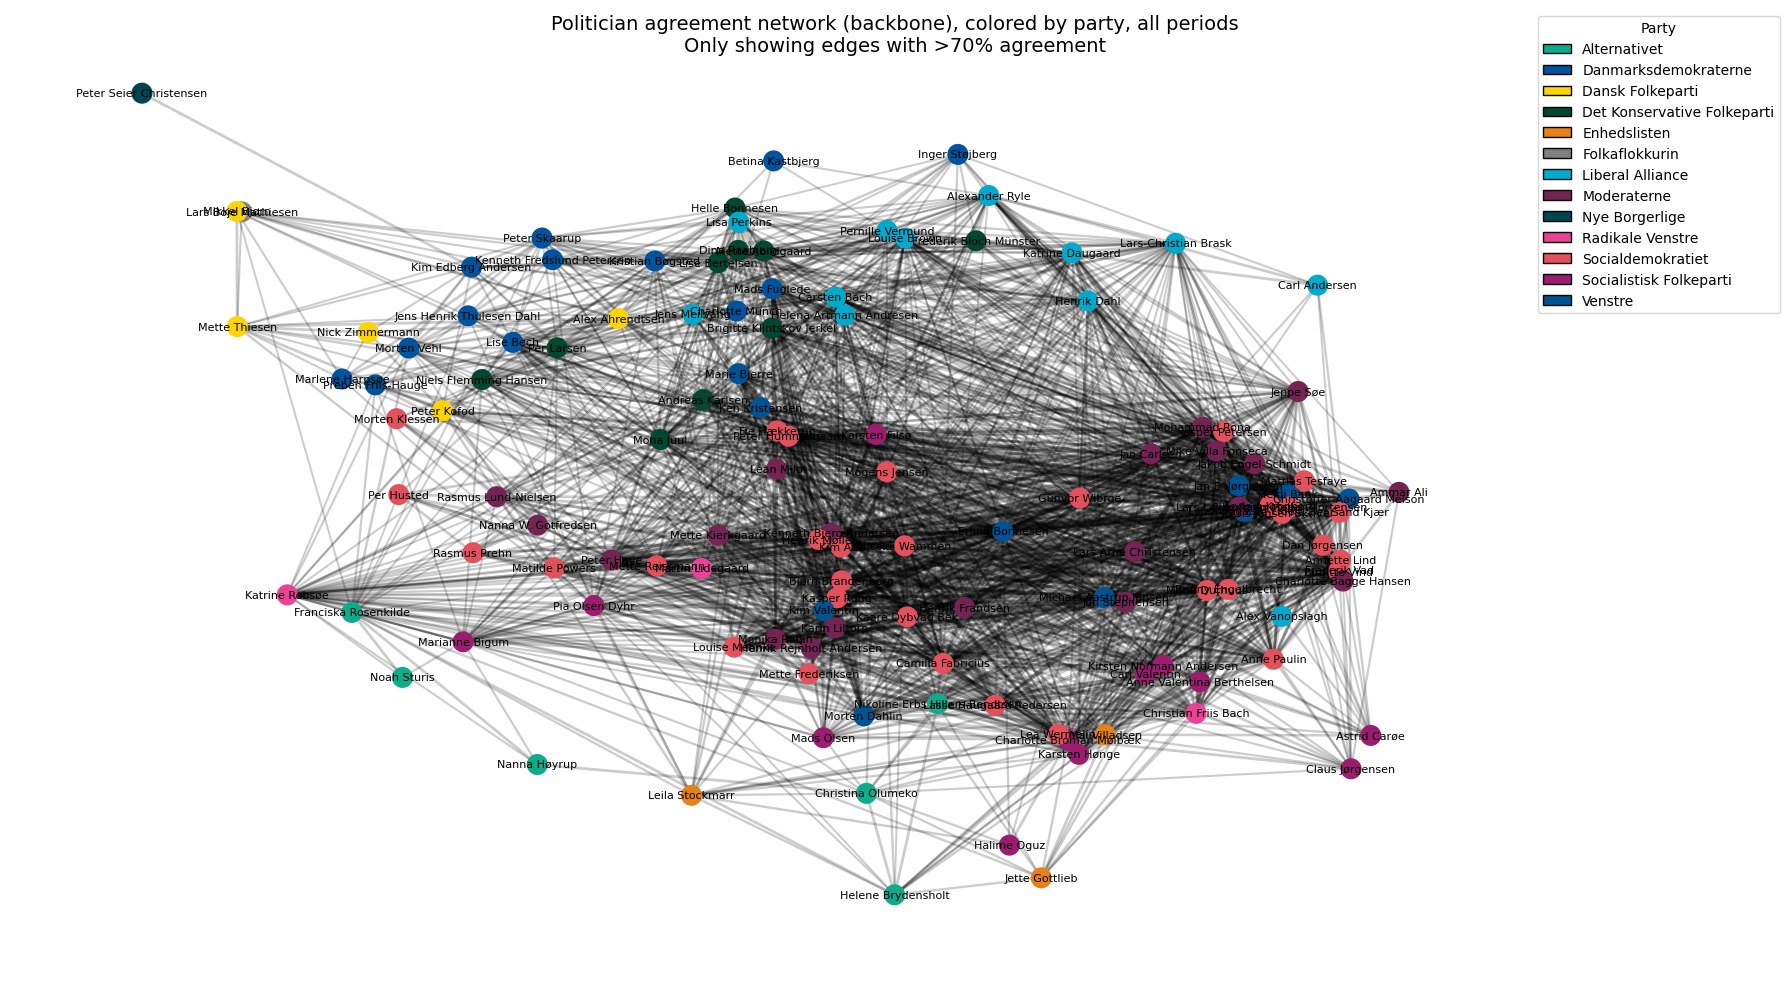

In [103]:
edgelist_and_graph_to_visualization(df_backbone,0.7,stats=True)

In [105]:
# Step 1: Aggregate data
df_agg = filter_and_aggregate(all_politician_edges, periods=[65, 66, 67])

# Step 2: Build full network and calculate centrality
G_full = nx.from_pandas_edgelist(df_agg, 'source', 'target', edge_attr='weight')

# Centrality on FULL network
degree_full = nx.degree_centrality(G_full)
betweenness_full = nx.betweenness_centrality(G_full, weight='weight')
closeness_full = nx.closeness_centrality(G_full, distance='weight')
eigenvector_full = nx.eigenvector_centrality(G_full, weight='weight', max_iter=1000)

# Step 3: Apply backboning
df_backbone, stats, G_backbone = apply_backboning(df_agg, min_votes_threshold=10, alpha=0.1)

# Centrality on BACKBONE network
degree_backbone = nx.degree_centrality(G_backbone)
betweenness_backbone = nx.betweenness_centrality(G_backbone, weight='weight')
closeness_backbone = nx.closeness_centrality(G_backbone, distance='weight')

# Step 4: Compare!
# Who has high centrality in both? (consistently important)
# Who drops after backboning? (redundantly connected)
# Who increases after backboning? (structurally critical bridges)

Calculating HSS score...



BACKBONING SUMMARY

Original network:
  Nodes: 261
  Edges: 24025

After min_votes_threshold=10:
  Nodes: 236 (90.4%)
  Edges: 20842 (86.8%)

After backbone extraction (alpha=0.1):
  Nodes: 204 (78.2%)
  Edges: 6775 (28.2%)

Backbone edge statistics:
  Average weight (agreement rate): 0.731
  Average HSS score: 0.2384
  Weight range: [0.100, 1.000]
  HSS score range: [0.1017, 0.4958]



In [111]:
from political_centrality_analysis import calculate_centrality_measures

In [113]:
df_agg = filter_and_aggregate(all_politician_edges, periods=[65, 66, 67])
# Step 2: Build full network and calculate centrality
G_full = nx.from_pandas_edgelist(df_agg, 'source', 'target', edge_attr='weight')

In [122]:
from political_centrality_analysis import calculate_centrality_measures

df_agg_filtered = df_agg[df_agg['weight'] > 0.6]
G_full = nx.from_pandas_edgelist(df_agg_filtered, 'source', 'target', edge_attr='weight')

# Step 1: Aggregate data
df_agg = filter_and_aggregate(all_politician_edges, periods=[65, 66, 67])

# Step 2: Build full network
df_agg_filtered = df_agg[df_agg['weight'] > 0.6]
G_full = nx.from_pandas_edgelist(df_agg_filtered, 'source', 'target', edge_attr='weight')

# Step 3: Calculate centrality on full network (will now work!)
centrality_full = calculate_centrality_measures(G_full, "Full Network")

# Step 4: Apply backboning
df_backbone, stats, G_backbone = apply_backboning(df_agg, min_votes_threshold=10, alpha=0.1)

# Step 5: Calculate centrality on backbone
centrality_backbone = calculate_centrality_measures(G_backbone, "Backbone Network")



Calculating centrality measures for Full Network
Network size: 261 nodes, 15095 edges
  - Computing degree centrality...
  - Computing betweenness centrality...
  - Computing closeness centrality...
  - Computing eigenvector centrality...
✓ Centrality calculations complete for Full Network



Calculating HSS score...



BACKBONING SUMMARY

Original network:
  Nodes: 261
  Edges: 24025

After min_votes_threshold=10:
  Nodes: 236 (90.4%)
  Edges: 20842 (86.8%)

After backbone extraction (alpha=0.1):
  Nodes: 204 (78.2%)
  Edges: 6775 (28.2%)

Backbone edge statistics:
  Average weight (agreement rate): 0.731
  Average HSS score: 0.2384
  Weight range: [0.100, 1.000]
  HSS score range: [0.1017, 0.4958]


Calculating centrality measures for Backbone Network
Network size: 204 nodes, 6775 edges
  - Computing degree centrality...
  - Computing betweenness centrality...
  - Computing closeness centrality...
  - Computing eigenvector centrality...
✓ Centrality calculations complete for Backbone Network



In [123]:
# Or use the all-in-one function:
centrality_full, centrality_backbone = full_centrality_analysis(
    df_agg, df_backbone, G_full, G_backbone
)


COMPREHENSIVE CENTRALITY ANALYSIS

Calculating centrality measures for Full Network
Network size: 261 nodes, 15095 edges
  - Computing degree centrality...
  - Computing betweenness centrality...
  - Computing closeness centrality...
  - Computing eigenvector centrality...
✓ Centrality calculations complete for Full Network


Calculating centrality measures for Backbone Network
Network size: 204 nodes, 6775 edges
  - Computing degree centrality...
  - Computing betweenness centrality...
  - Computing closeness centrality...
  - Computing eigenvector centrality...
✓ Centrality calculations complete for Backbone Network


FULL NETWORK - TOP POLITICIANS BY CENTRALITY

────────────────────────────────────────────────────────────────────────────────
Top 10 by Degree Centrality (Full Network)
────────────────────────────────────────────────────────────────────────────────
Rank   Politician                               Party                     Score     
───────────────────────────────────

In [86]:
df_backbone.head()

,source,target,source_party,target_party,total_votes_shared,total_votes_agreed,weight,hss_score
0,Alex Ahrendtsen,Alex Vanopslagh,Dansk Folkeparti,Liberal Alliance,53,50.0,0.943396,0.496894
1,Alex Ahrendtsen,Alexander Ryle,Dansk Folkeparti,Liberal Alliance,589,397.0,0.674024,0.493789
2,Alex Ahrendtsen,Ammar Ali,Dansk Folkeparti,Moderaterne,79,39.0,0.493671,0.490683
3,Alex Ahrendtsen,Anders Kronborg,Dansk Folkeparti,Socialdemokratiet,792,448.0,0.565657,0.487578
4,Alex Ahrendtsen,Andreas Karlsen,Dansk Folkeparti,Det Konservative Folkeparti,21,20.0,0.952381,0.003106


In [88]:
G = nx.from_pandas_edgelist(df_backbone, 'source', 'target', edge_attr='weight')

In [90]:
G.nodes

NodeView(('Alex Ahrendtsen', 'Alex Vanopslagh', 'Alexander Ryle', 'Ammar Ali', 'Anders Kronborg', 'Andreas Karlsen', 'Anna Falkenberg', 'Anne Paulin', 'Anne Valentina Berthelsen', 'Annette Lind', 'Astrid Carøe', 'Benny Engelbrecht', 'Betina Kastbjerg', 'Birgitte Vind', 'Bjørn Brandenborg', 'Brigitte Klintskov Jerkel', 'Camilla Fabricius', 'Carl Andersen', 'Carl Valentin', 'Carsten Bach', 'Charlotte Bagge Hansen', 'Charlotte Broman Mølbæk', 'Charlotte Munch', 'Christian Friis Bach', 'Christina Olumeko', 'Christoffer Aagaard Melson', 'Claus Jørgensen', 'Dan Jørgensen', 'Dina Raabjerg', 'Erling Bonnesen', 'Fie Hækkerup', 'Flemming Møller Mortensen', 'Franciska Rosenkilde', 'Frederik Bloch Münster', 'Frederik Vad', 'Gunvor Wibroe', 'Halime Oguz', 'Heidi Bank', 'Helena Artmann Andresen', 'Helene Brydensholt', 'Helle Bonnesen', 'Henrik Dahl', 'Henrik Frandsen', 'Henrik Møller', 'Henrik Rejnholt Andersen', 'Inger Støjberg', 'Jakob Engel-Schmidt', 'Jan Carlsen', 'Jan E. Jørgensen', 'Jens Henri

In [70]:
all_politician_edges.columns

Index(['source', 'target', 'source_party', 'target_party', 'Period',
       'total_votes_shared', 'total_votes_agreed', 'weight', 'topic'],
      dtype='object')

In [73]:
df_backbone.head()

,source,target,source_party,target_party,total_votes_shared,total_votes_agreed,weight,hss_score
0,Abbas Razvi,Alexander Grandt,Radikale Venstre,Socialdemokratiet,138,133.0,0.963768,0.499093
1,Abbas Razvi,Anders Kronborg,Radikale Venstre,Socialdemokratiet,160,147.0,0.918750,0.494555
2,Abbas Razvi,Andreas Steenberg,Radikale Venstre,Radikale Venstre,99,99.0,1.000000,0.490018
3,Abbas Razvi,Anne Honoré Østergaard,Radikale Venstre,Venstre,166,95.0,0.572289,0.487296
4,Abbas Razvi,Anne Rasmussen,Radikale Venstre,Venstre,69,44.0,0.637681,0.486388


In [75]:
edgelist_and_graph_to_visualization(df_backbone,0.7)

KeyError: 'Period'

Edges before filter: 67360, after filter: 36674


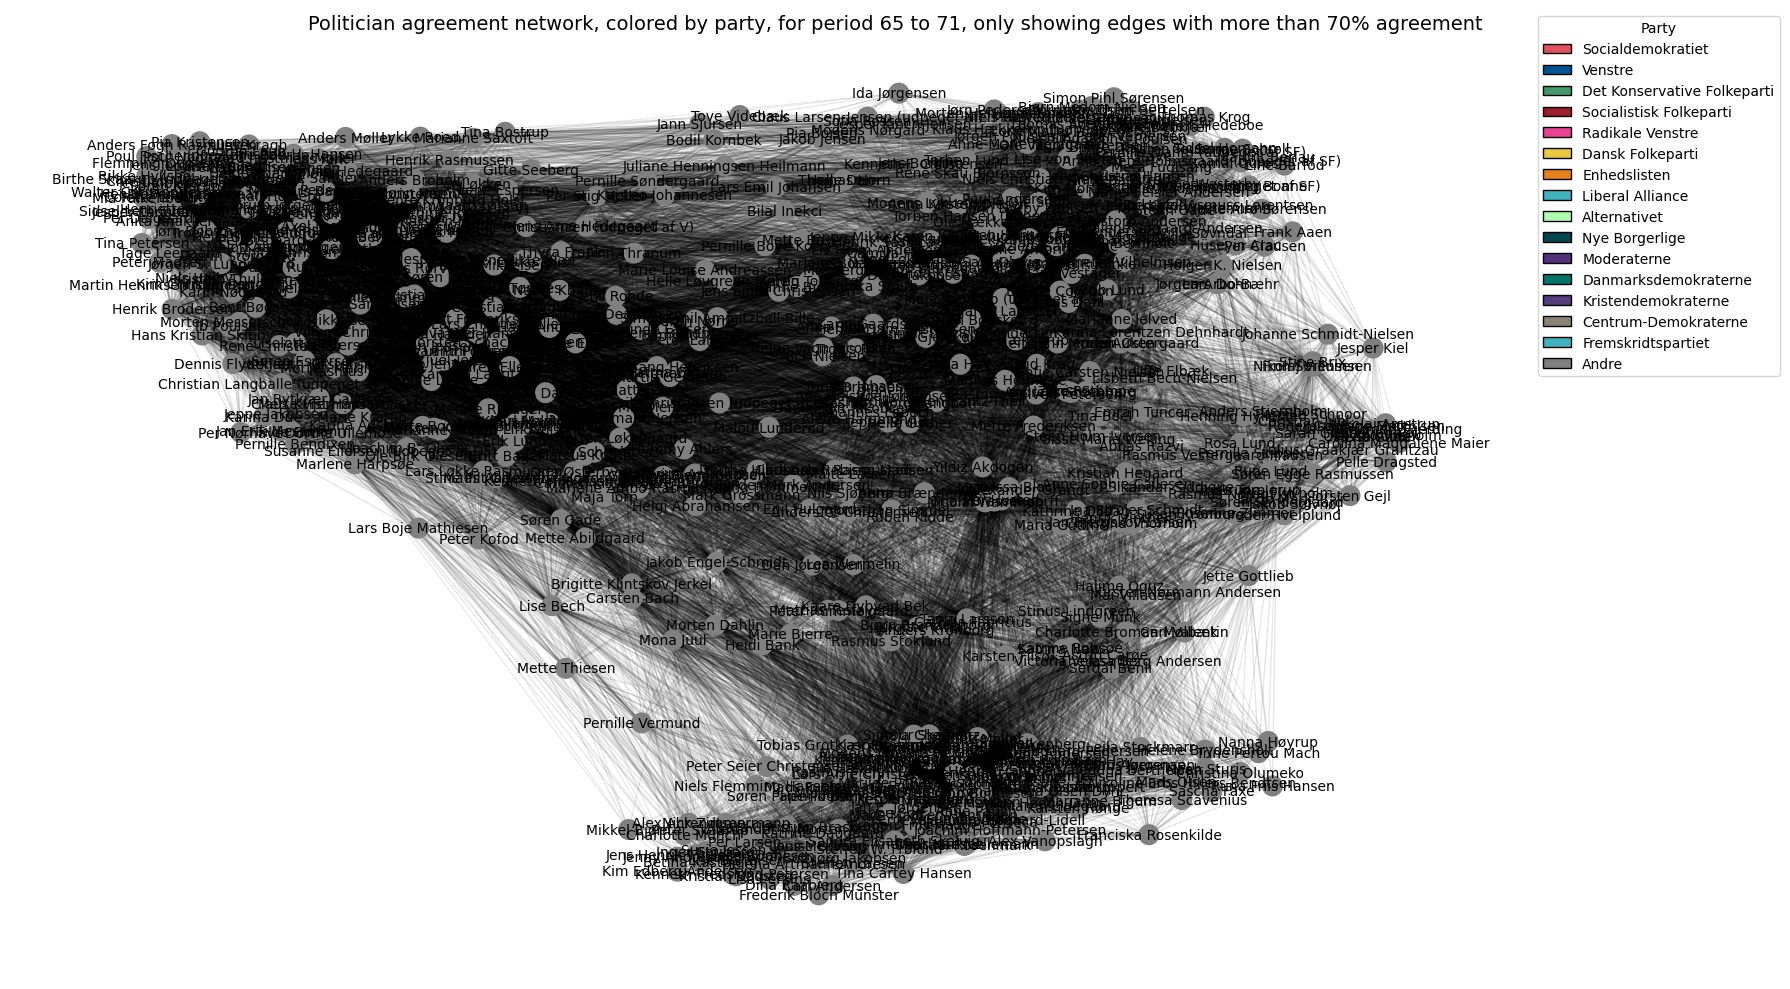

In [74]:
edgelist_and_graph_to_visualization(all_politician_edges,0.7)

In [ ]:
# Try different thresholds
for alpha in [0.0, 0.05, 0.1, 0.15, 0.2]:
    df_backbone, stats, G = apply_backboning(df_agg, 
                                              min_votes_threshold=10, 
                                              alpha=alpha)